In [1]:
import gwsurrogate

/home/omkarnm1401/miniconda3/envs/ut_codex/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
import sys
# sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
# import bhpt_utils

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
from gwtools.gwtools import minimize_norm_error_multi_mode

In [6]:
# add the path to the script directory
sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRSur1dq1e4 as bhptsur

/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates/../data
**** Surrogate loaded: BHPTNRSur1dq1e4 ****


In [7]:
import matplotlib as mpl

sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
import bhpt_utils
mpl.rcdefaults()

In [8]:
plot_dir = 'Notebook_plots/'

In [9]:
nrsur = gwsurrogate.LoadSurrogate('NRHybSur3dq8')

Loaded NRHybSur3dq8 model


In [10]:
# convience wrapper for calling the NRHybSur3dq8 model
def generate_nrsur(q_input, f_low=None, t_start=None):
    chiA = [0, 0, 0.0]
    chiB = [0, 0, 0.0]
    dt = 0.1        # step size, Units of M
    if f_low==None:
        f_low=5e-3
    if t_start==None:
        t_start=-5000.1
    # dyn stands for dynamics and is always None for this model
    t, h, dyn = nrsur(q_input, chiA, chiB, dt=dt, f_low=f_low) 
    # we only take the last 5000M long waveform to calibrate
    indx = np.where(t>=t_start)
    t = t[indx]
    for mode in h.keys():
        h[mode] = h[mode][indx]
    return t,h

In [11]:
tnr, h_NRHybSur3dq8 = generate_nrsur(q_input=5)

In [12]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhpt, hbhpt = bhptsur.generate_surrogate(q=5, modes=h_NRHybSur3dq8.keys(), calibrated=False, neg_modes=False)

**** warning **** : modes are NOT NR calibrated - waveforms only have 0PA contribution


In [13]:
q_input = 5
mass_norm = 1/(1+1/q_input)

In [14]:
h_NR_22 = h_NRHybSur3dq8[(2, 2)]

In [15]:
import gwtools

In [16]:
def mathcalE_error(h1, h2):
    """
    Compute time-domain waveform error.

    Calculates the normalized L2 error between two waveforms using the metric
    defined in Eq. 21 of https://arxiv.org/pdf/1701.00550.pdf

    Parameters:
    -----------
    h1 : array (complex)
        Reference waveform (used for normalization)
    h2 : array (complex)
        Comparison waveform (same length as h1)

    Returns:
    --------
    normed_errs : float
        Normalized error: (||h1||² + ||h2||² - 2*Re(<h1,h2>)) / (2*||h1||²)
        Value of 0 indicates perfect agreement, larger values indicate greater disagreement

    Notes:
    ------
    - Assumes h1 is the reference waveform and normalizes by its magnitude
    - Both waveforms should have the same time sampling
    - The metric is symmetric in the numerator but asymmetric due to normalization by ||h1||²
    """
    # Compute norms squared
    n1Sqr = np.sum(np.abs(h1)**2)
    n2Sqr = np.sum(np.abs(h2)**2)

    # Compute inner product
    dots = np.array([h1[i] * (h2[i].conjugate()) for i in range(len(h1))])
    sdot = np.real(np.sum(dots))

    # Normalize error by reference waveform magnitude
    normed_errs = ((n1Sqr + n2Sqr) - 2 * sdot) / (2 * n1Sqr)

    return normed_errs

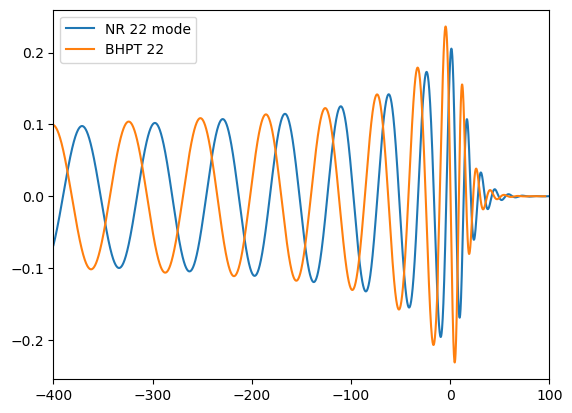

In [17]:
plt.plot(tnr, np.real(h_NR_22), label = 'NR 22 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(2,2)])  * mass_norm, label = 'BHPT 22')

plt.xlim(-400, 100)
plt.legend()

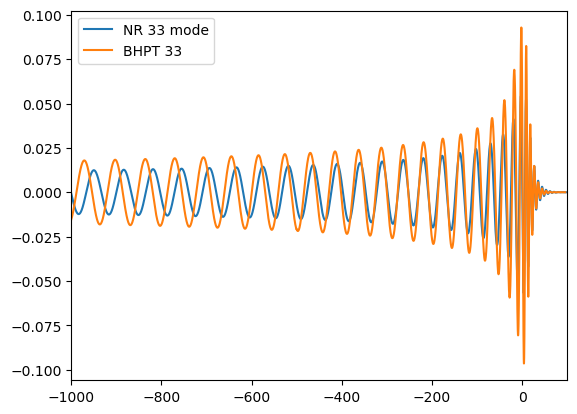

In [18]:
h_nr_33 = h_NRHybSur3dq8[(3, 3)]

plt.plot(tnr, np.real(h_nr_33), label = 'NR 33 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(3,3)])  * mass_norm, label = 'BHPT 33')

plt.xlim(-1000, 100)
plt.legend()

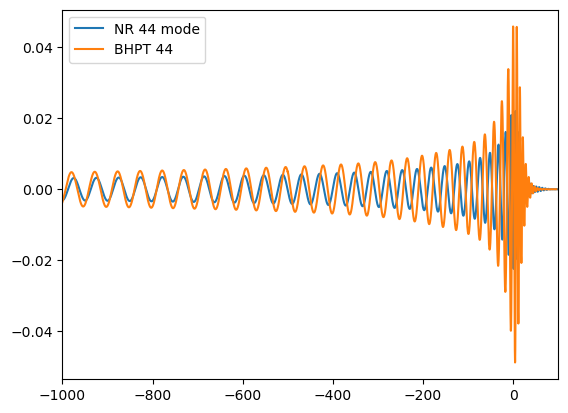

In [19]:
h_nr_44 = h_NRHybSur3dq8[(4, 4)]

plt.plot(tnr, np.real(h_nr_44), label = 'NR 44 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(4, 4)])  * mass_norm, label = 'BHPT 44')

plt.xlim(-1000, 100)
plt.legend()

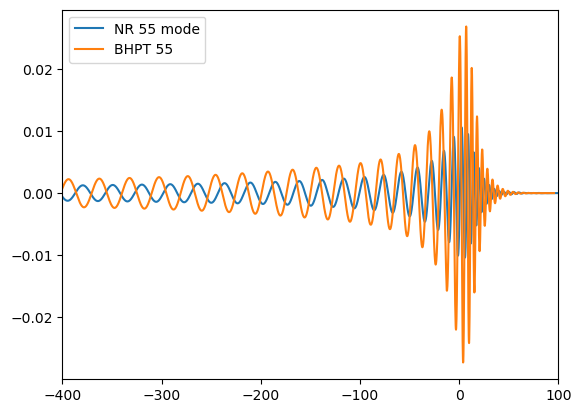

In [20]:
h_nr_55 = h_NRHybSur3dq8[(5, 5)]

plt.plot(tnr, np.real(h_nr_55), label = 'NR 55 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(5, 5)])  * mass_norm, label = 'BHPT 55')

plt.xlim(-400, 100)
plt.legend()

In [21]:
baseline_t = tbhpt * mass_norm
baseline_common = (tnr >= baseline_t[0]) & (tnr <= baseline_t[-1])
h_bhpt_interp = gwtools.interpolate_h(
    baseline_t, hbhpt[(2,2)], tnr[baseline_common]
)
mathcalE_error(h_NR_22[baseline_common], h_bhpt_interp)

np.float64(1.3585419153111171)

In [22]:
# %load scaling_stricter_physical_smooth.md
# Reduced stricter physical smooth q=5 (2,2) scaling fit

#Using a reduced smooth fit for `alpha(theta)` and `beta(theta)` in
#merger-centered physical time, with constant pre-cutoff branches, I get:

#```python

nu = q_input / (1 + q_input)**2

t_bhpt_merger = 1.10958353616297e-07
t_nr_merger = -0.837744212698453
def theta(t):
    return nu * (t - t_bhpt_merger)
#Theta_nr = nu * (t_nr - t_nr_merger)
#```
theta_cut = -40.211386551818
theta_transition_width = 26.9556318610348
theta_transition_end = theta_cut + theta_transition_width
t_bhpt_cut = t_bhpt_merger + theta_cut / nu  # -289.521983062131
Theta_cut_nr = -32.109908488572
t_cut_nr = t_nr_merger + Theta_cut_nr / nu  # -232.029085330417


def smooth_constant_to_line(theta_values, left_value, right_edge_value, right_slope):
    input_is_scalar = np.ndim(theta_values) == 0
    theta_arr = np.atleast_1d(np.asarray(theta_values, dtype=float))
    dtheta = theta_arr - theta_cut

    out = np.empty_like(theta_arr, dtype=float)
    left = dtheta <= 0.0
    right = dtheta >= theta_transition_width
    middle = ~(left | right)

    out[left] = left_value
    out[right] = right_edge_value + right_slope * (dtheta[right] - theta_transition_width)

    if np.any(middle):
        z = dtheta[middle] / theta_transition_width
        h00 = 2.0 * z**3 - 3.0 * z**2 + 1.0
        h01 = -2.0 * z**3 + 3.0 * z**2
        h11 = z**3 - z**2
        out[middle] = (
            h00 * left_value
            + h01 * right_edge_value
            + h11 * theta_transition_width * right_slope
        )

    if input_is_scalar:
        return float(out[0])
    return out.reshape(np.asarray(theta_values).shape)


def alpha(t):
    return smooth_constant_to_line(
        theta(t),
        0.808778897989962,
        0.813372710961577,
        -0.00680018833178102,
    )


def beta(t):
    return smooth_constant_to_line(
        theta(t),
        0.804278517755289,
        0.808357178154863,
        0.00161139010664821,
    )


beta_integral = np.r_[
    0.0,
    np.cumsum(0.5 * (beta(tbhpt[:-1]) + beta(tbhpt[1:])) * np.diff(tbhpt)),
]
beta_integral_cut = np.interp(t_bhpt_cut, tbhpt, beta_integral)


def tau(t):
    input_is_scalar = np.ndim(t) == 0
    t_arr = np.atleast_1d(np.asarray(t, dtype=float))
    integral = np.interp(t_arr, tbhpt, beta_integral)
    out = t_cut_nr + integral - beta_integral_cut

    if input_is_scalar:
        return float(out[0])
    return out.reshape(np.asarray(t).shape)




# Phase rotation:

# ```python
phi0 = 1.24976456081864  # radians, principal value
phi0_unwrapped = phi0
#```

# Applied as:

# ```python
tbhpt_extcal = tau(tbhpt)

hbhpt_extcal = {
    (2, 2): alpha(tbhpt) * hbhpt[(2,2)]
}
#```

# The fit uses raw `BHPTNRSur1dq1e4` with `calibrated=False`, `NRHybSur3dq8` with `dt=0.1`, `f_low=5e-3`, and the `mathcalE_error` definition in `NRBHP_ansatz.py` with NR as the reference waveform.

# Diagnostics:

# - q: `5`
# - mode: `(2, 2)`
# - transition interval in theta: `[-40.211386551818, -13.2557546907833]`
# - optimized cutoff in NR time: `-232.029085330417`
# - corresponding BHPT source split: `-289.521983062131`
# - common NR support: `[-4999.9377442127, 98.5622557873012]`
# - optimizer downsampled `mathcalE`: `0.000149235734978704`
# - full-window `mathcalE`: `0.000149607512601296`
# - pre-transition local `mathcalE`: `5.97737475151136e-05`
# - smooth-transition local `mathcalE`: `0.000180926074469447`
# - post-transition local `mathcalE`: `0.000914034223340297`
# - pre-cutoff alpha and beta slopes: `0` by construction

#No extrapolated BHPT samples are used. The source interval is inside the raw BHPT support and endpoint BHPT values are obtained by interpolation within that support.

In [23]:
[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode(tau(tbhpt),  hbhpt_extcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

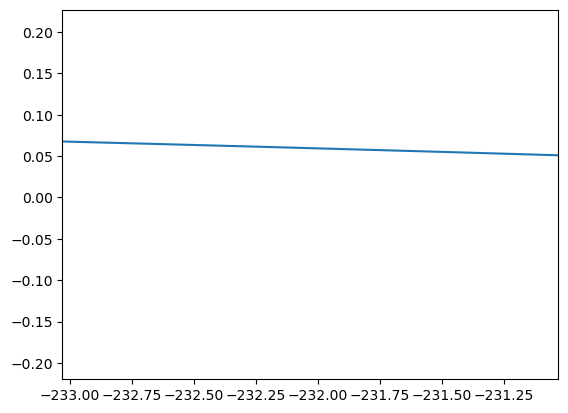

In [31]:
plt.plot(tbhpt_extcal, hbhpt_extcal[(2,2)])

plt.xlim(float(tau(t_bhpt_cut) - 1), float(tau(t_bhpt_cut) + 1))
#plt.ylim(-0.1, -0.07)
plt.show()

In [38]:
alpha(t_bhpt_cut+1000)

0.05220548258251789

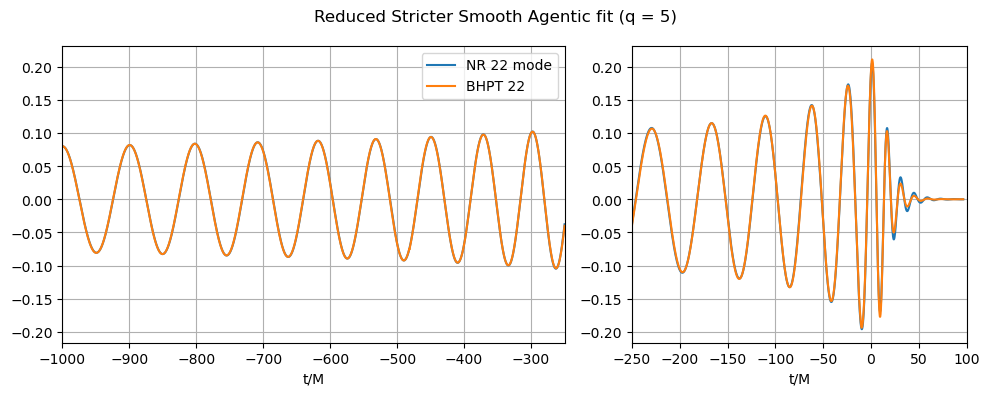

In [26]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax1.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax2.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

plt.suptitle('Reduced Stricter Smooth Agentic fit (q = 5)')

plt.tight_layout()
plt.savefig(plot_dir + 'Stricter_agentic_fit_physical_waveform_smooth.pdf')
#plt.show()

In [27]:
mathcalE_error(h_bhpt_aligned[(2,2)], h_nr_aligned[(2,2)])

np.float64(0.00014978943219864455)

In [28]:
modes = [(2,2)]
ab = bhpt_utils.all_alpha_beta_1D_scaling_params(q_input, modes)
print(ab)

{'beta': 0.803656511773389, 'alpha_l2m2': 0.804414592200569}


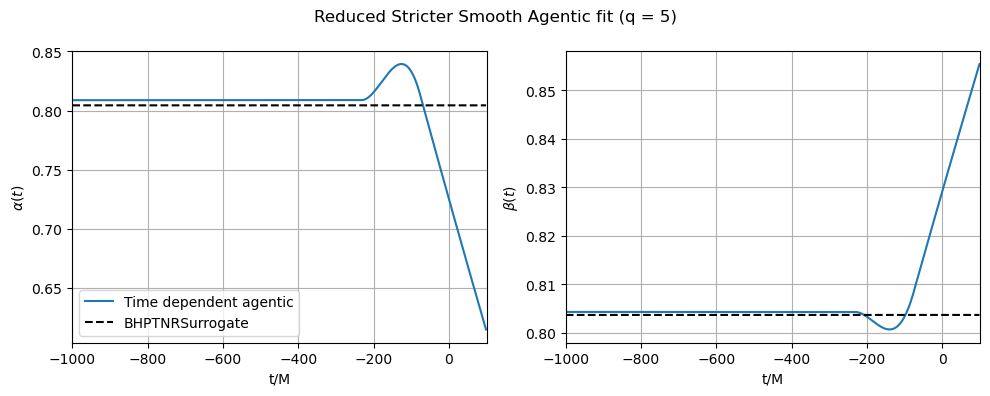

In [29]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [2, 2]}
)



#ax1.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax1.plot(tbhpt_extcal, alpha(tbhpt), label = 'Time dependent agentic')
ax1.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['alpha_l2m2'], label = 'BHPTNRSurrogate', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, 100)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.set_ylabel(r'$\alpha(t)$')
ax1.legend()

#ax2.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax2.plot(tbhpt_extcal, beta(tbhpt))
ax2.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['beta'], linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')
ax2.set_ylabel(r'$\beta(t)$')

ax2.set_xlim(-1000, 100)
ax2.grid(True)

plt.suptitle('Reduced Stricter Smooth Agentic fit (q = 5)')


plt.tight_layout()
plt.savefig(plot_dir + 'Stricter_agentic_fit_physical_params_smooth.pdf')
#plt.show()

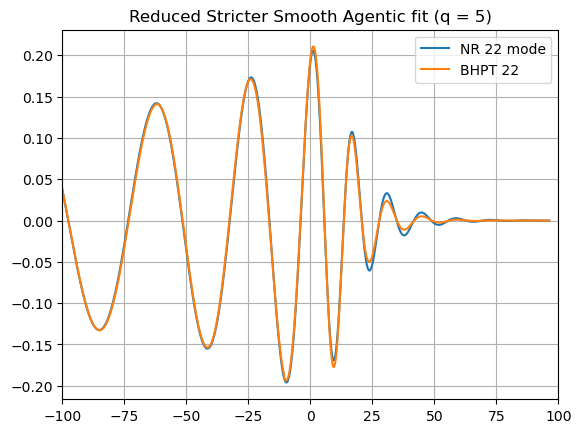

In [30]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
plt.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

plt.xlim(-100, 100)
plt.title('Reduced Stricter Smooth Agentic fit (q = 5)')
plt.grid(True)

plt.legend()
plt.savefig(plot_dir + 'Stricter_agentic_fit_physical_zoomed_smooth.pdf')
plt.show()